# Pipeline Complet — Prévision CA 2026
## Chargement → Feature Selection (RFE/Forward/Backward) → Training → Prédiction

## 1. Imports

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import clickhouse_connect
import warnings
import json
import joblib
import plotly.graph_objects as go

from sklearn.linear_model import (LinearRegression, Ridge, Lasso,
                                   ElasticNet, HuberRegressor)
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               GradientBoostingRegressor, AdaBoostRegressor)
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.feature_selection import RFE, SequentialFeatureSelector

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='whitegrid')
print('✅ Imports OK')

✅ Imports OK


## 2. Chargement depuis ClickHouse — Toutes les dimensions

In [21]:
client = clickhouse_connect.get_client(
    host='clickhouse', port=8123,
    user='default', password='clickhouse123',
    database='gold'
)

df = client.query_df("""
SELECT
    d.Year                               AS year,
    d.Month                              AS month,
    d.Quarter                            AS quarter,
    SUM(f.LinePrice)                     AS total_sales,
    SUM(f.Quantity)                      AS total_quantity,
    COUNT(DISTINCT f.DocumentCode)       AS nb_documents,
    COUNT(DISTINCT f.ClientSK)           AS nb_clients,

    -- dim_client
    COUNT(DISTINCT CASE WHEN c.IsBTOB = 1 THEN f.ClientSK END)  AS nb_clients_btob,
    COUNT(DISTINCT CASE WHEN c.IsBTOB = 0 THEN f.ClientSK END)  AS nb_clients_btoc,
    COUNT(DISTINCT CASE WHEN c.IsActive = 1 THEN f.ClientSK END) AS nb_clients_actifs,

    -- dim_item
    COUNT(DISTINCT i.Family)             AS nb_families,
    COUNT(DISTINCT i.Brand)              AS nb_brands,
    COUNT(DISTINCT f.ItemSK)             AS nb_produits,

    -- dim_geographical_area
    COUNT(DISTINCT f.GeographicalAreaSK) AS nb_regions,

    -- dim_warehouse
    COUNT(DISTINCT f.WarehouseSK)        AS nb_warehouses,

    -- Métriques financières
    AVG(f.DiscountPercentage)            AS avg_discount,
    SUM(f.DiscountAmount)                AS total_discount,
    AVG(f.LinePrice)                     AS avg_line_price,
    AVG(f.CostPrice)                     AS avg_cost_price

FROM gold.fact_sales AS f
JOIN gold.dim_date AS d               ON f.DateSK   = d.DateSK
JOIN gold.dim_client AS c             ON f.ClientSK = c.ClientSK
JOIN gold.dim_item AS i               ON f.ItemSK   = i.ItemSK
WHERE f.DocumentTypeSK IN (4, 1, 5)
  AND f.LinePrice IS NOT NULL
GROUP BY year, month, quarter
ORDER BY year, month
""")

df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
print(f'✅ {len(df)} mois chargés — shape : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
df.head()

✅ 51 mois chargés — shape : (51, 20)
Colonnes : ['year', 'month', 'quarter', 'total_sales', 'total_quantity', 'nb_documents', 'nb_clients', 'nb_clients_btob', 'nb_clients_btoc', 'nb_clients_actifs', 'nb_families', 'nb_brands', 'nb_produits', 'nb_regions', 'nb_warehouses', 'avg_discount', 'total_discount', 'avg_line_price', 'avg_cost_price', 'date']


,year,month,quarter,total_sales,total_quantity,nb_documents,nb_clients,nb_clients_btob,nb_clients_btoc,nb_clients_actifs,nb_families,nb_brands,nb_produits,nb_regions,nb_warehouses,avg_discount,total_discount,avg_line_price,avg_cost_price,date
0,2021,3,1,404.06,6,1,1,0,1,1,3,6,6,1,2,15.00,60.61,67.34,55.83,2021-03-01
1,2022,1,1,"591,407.94",10983,1125,197,40,157,159,41,163,3225,9,3,9.28,"44,802.24",81.56,83.35,2022-01-01
2,2022,2,1,"576,097.45",10770,1263,190,40,150,158,40,176,3327,9,3,9.69,"36,225.76",70.17,82.47,2022-02-01
3,2022,3,1,"680,213.89",11488,1304,200,40,160,167,40,178,3497,9,3,7.93,"40,184.68",88.80,89.29,2022-03-01
4,2022,4,2,"650,789.55",11385,1093,224,41,183,188,39,181,3264,9,4,9.09,"47,939.71",92.52,90.74,2022-04-01


## 3. Nettoyage — Jan 2022 → Déc 2025

In [22]:
print(f'Avant nettoyage : {len(df)} mois')
print('Mois incomplets :')
print(df[
    (df['date'] < '2022-01-01') | (df['date'] >= '2026-01-01')
][['date', 'total_sales']].to_string(index=False))

df = df[
    (df['date'] >= '2022-01-01') & (df['date'] < '2026-01-01')
].reset_index(drop=True)

print(f'\nAprès nettoyage : {len(df)} mois')
print(f'Période         : {df["date"].min().strftime("%b %Y")} → {df["date"].max().strftime("%b %Y")}')
print(f'Prédiction cible: Jan 2026 → Déc 2026')

Avant nettoyage : 51 mois
Mois incomplets :
      date  total_sales
2021-03-01       404.06
2026-01-01 1,218,358.52
2026-02-01   114,247.11

Après nettoyage : 48 mois
Période         : Jan 2022 → Dec 2025
Prédiction cible: Jan 2026 → Déc 2026


## 4. Feature Engineering

In [23]:
df_ml = df[[
    'date', 'year', 'month', 'quarter',
    'total_sales',
    'total_quantity', 'nb_documents', 'nb_clients',
    'nb_clients_btob', 'nb_clients_btoc', 'nb_clients_actifs',
    'nb_families', 'nb_brands', 'nb_produits',
    'nb_regions', 'nb_warehouses',
    'avg_discount', 'total_discount', 'avg_line_price', 'avg_cost_price',
]].copy()

# Variables temporelles
df_ml['semester']    = df_ml['month'].apply(lambda x: 1 if x <= 6 else 2)
df_ml['is_summer']   = df_ml['month'].isin([7, 8]).astype(int)
df_ml['is_end_year'] = df_ml['month'].isin([11, 12]).astype(int)
df_ml['is_january']  = (df_ml['month'] == 1).astype(int)

# Lag features
df_ml['lag_1']  = df_ml['total_sales'].shift(1)
df_ml['lag_12'] = df_ml['total_sales'].shift(12)

# lag_12 fallback sur moyenne mensuelle
monthly_avg = df_ml.groupby('month')['total_sales'].mean()
df_ml['lag_12'] = df_ml.apply(
    lambda row: monthly_avg[row['month']] if pd.isna(row['lag_12']) else row['lag_12'],
    axis=1
)

# Rolling
df_ml['rolling_mean_3'] = df_ml['total_sales'].shift(1).rolling(3).mean()

df_ml = df_ml.dropna().reset_index(drop=True)

print(f'✅ Dataset prêt : {df_ml.shape}')
print(f'Période : {df_ml["date"].min().strftime("%b %Y")} → {df_ml["date"].max().strftime("%b %Y")}')
df_ml.head()

✅ Dataset prêt : (45, 27)
Période : Apr 2022 → Dec 2025


,date,year,month,quarter,total_sales,total_quantity,nb_documents,nb_clients,nb_clients_btob,nb_clients_btoc,...,total_discount,avg_line_price,avg_cost_price,semester,is_summer,is_end_year,is_january,lag_1,lag_12,rolling_mean_3
0,2022-04-01,2022,4,2,"650,789.55",11385,1093,224,41,183,...,"47,939.71",92.52,90.74,1,0,0,0,"680,213.89","988,770.24","615,906.42"
1,2022-05-01,2022,5,2,"734,335.68",14813,1199,220,45,175,...,"40,078.02",98.66,97.18,1,0,0,0,"650,789.55","1,148,927.19","635,700.29"
2,2022-06-01,2022,6,2,"754,273.83",12461,1280,223,45,178,...,"42,263.58",98.37,99.61,1,0,0,0,"734,335.68","1,137,109.13","688,446.37"
3,2022-07-01,2022,7,3,"787,031.57",14561,1112,218,48,170,...,"51,443.72",112.71,105.99,2,1,0,0,"754,273.83","1,276,582.07","713,133.02"
4,2022-08-01,2022,8,3,"847,028.15",14118,1169,213,49,164,...,"49,778.81",107.52,102.79,2,1,0,0,"787,031.57","1,189,156.28","758,547.03"


## 5. Définition des features candidates + Corrélation

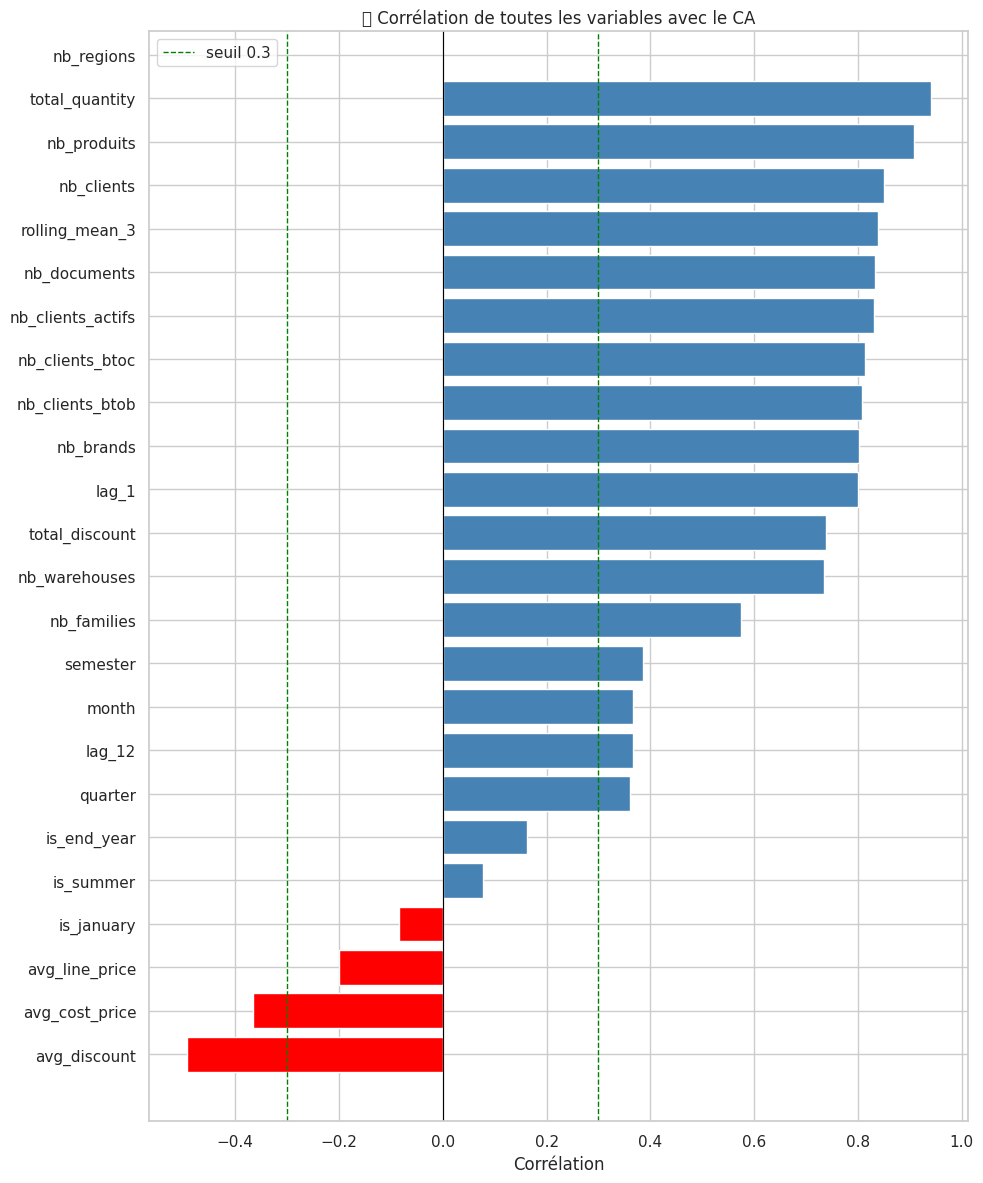


Corrélations :
avg_discount        -0.49
avg_cost_price      -0.37
avg_line_price      -0.20
is_january          -0.08
is_summer            0.08
is_end_year          0.16
quarter              0.36
lag_12               0.37
month                0.37
semester             0.39
nb_families          0.58
nb_warehouses        0.74
total_discount       0.74
lag_1                0.80
nb_brands            0.80
nb_clients_btob      0.81
nb_clients_btoc      0.81
nb_clients_actifs    0.83
nb_documents         0.83
rolling_mean_3       0.84
nb_clients           0.85
nb_produits          0.91
total_quantity       0.94
nb_regions            NaN

✅ 24 features candidates


In [24]:
TARGET = 'total_sales'

ALL_FEATURES = [
    # Temporelles
    'month', 'quarter', 'semester',
    'is_summer', 'is_end_year', 'is_january',
    # Lags
    'lag_1', 'lag_12', 'rolling_mean_3',
    # Métriques base
    'total_quantity', 'nb_documents', 'nb_clients',
    # dim_client
    'nb_clients_btob', 'nb_clients_btoc', 'nb_clients_actifs',
    # dim_item
    'nb_families', 'nb_brands', 'nb_produits',
    # dim_geo + warehouse
    'nb_regions', 'nb_warehouses',
    # Financières
    'avg_discount', 'total_discount', 'avg_line_price', 'avg_cost_price',
]

# Vérifier que toutes existent
ALL_FEATURES = [f for f in ALL_FEATURES if f in df_ml.columns]

corr = df_ml[ALL_FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['red' if v < 0 else 'steelblue' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0,    color='black', linewidth=0.8)
ax.axvline(0.3,  color='green', linewidth=1, linestyle='--', label='seuil 0.3')
ax.axvline(-0.3, color='green', linewidth=1, linestyle='--')
ax.set_title('📊 Corrélation de toutes les variables avec le CA')
ax.set_xlabel('Corrélation')
ax.legend()
plt.tight_layout()
plt.show()

print('\nCorrélations :')
print(corr.to_string())

print(f'\n✅ {len(ALL_FEATURES)} features candidates')

## 6. Split temporel + Normalisation

Train : 40 mois (Apr 2022 → Jul 2025)
Test  : 5 mois (Aug 2025 → Dec 2025)

✅ Scaler appliqué sur 24 features


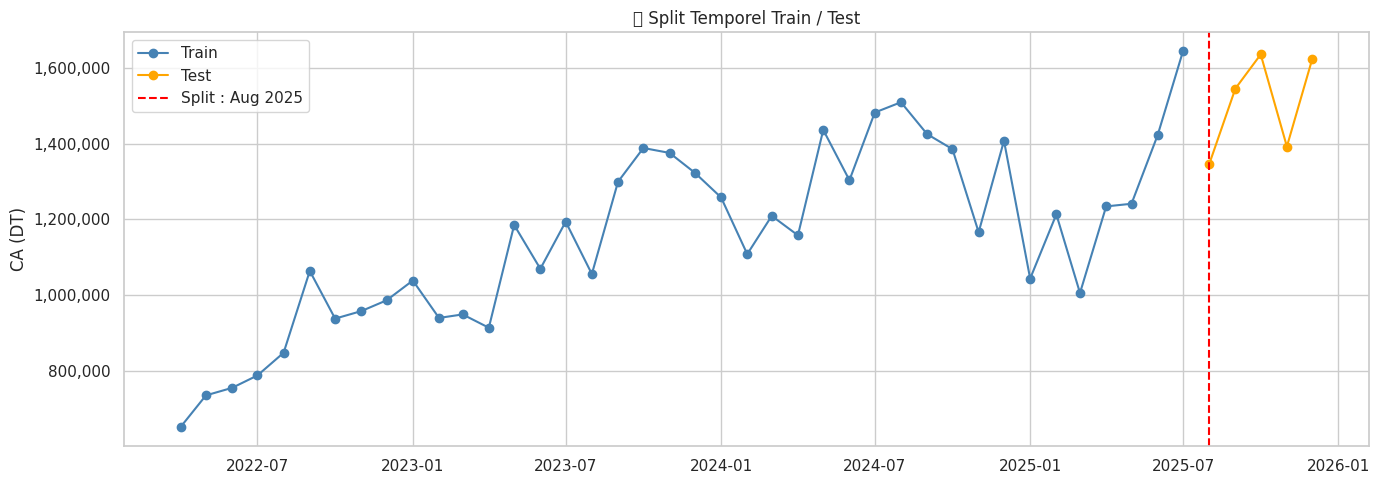

In [25]:
split_idx  = int(len(df_ml) * 0.9)
split_date = df_ml.iloc[split_idx]['date']

X_all = df_ml[ALL_FEATURES]
y_all = df_ml[TARGET]

X_train_all = X_all.iloc[:split_idx]
X_test_all  = X_all.iloc[split_idx:]
y_train     = y_all.iloc[:split_idx]
y_test      = y_all.iloc[split_idx:]
df_train    = df_ml.iloc[:split_idx]
df_test     = df_ml.iloc[split_idx:]

scaler_all     = StandardScaler()
X_train_all_sc = scaler_all.fit_transform(X_train_all)
X_test_all_sc  = scaler_all.transform(X_test_all)

print(f'Train : {len(X_train_all)} mois ({df_train["date"].min().strftime("%b %Y")} → {df_train["date"].max().strftime("%b %Y")})')
print(f'Test  : {len(X_test_all)} mois ({df_test["date"].min().strftime("%b %Y")} → {df_test["date"].max().strftime("%b %Y")})')
print(f'\n✅ Scaler appliqué sur {len(ALL_FEATURES)} features')

fig, ax = plt.subplots()
ax.plot(df_train['date'], y_train, label='Train', color='steelblue', marker='o')
ax.plot(df_test['date'],  y_test,  label='Test',  color='orange',    marker='o')
ax.axvline(split_date, color='red', linestyle='--', label=f'Split : {split_date.strftime("%b %Y")}')
ax.set_title('📊 Split Temporel Train / Test')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

## 7. Sélection des features — RFE + Forward + Backward

In [26]:
tscv      = TimeSeriesSplit(n_splits=3)
N_FEATURES = 8  # nombre de features à sélectionner

print(f'🔍 Sélection de {N_FEATURES} features parmi {len(ALL_FEATURES)} candidates\n')

# ── 1. RFE ────────────────────────────────────────────────────
print('='*55)
print('1️⃣  RFE — Recursive Feature Elimination')
print('='*55)

rfe = RFE(estimator=LinearRegression(), n_features_to_select=N_FEATURES)
rfe.fit(X_train_all_sc, y_train)

features_rfe = [ALL_FEATURES[i] for i in range(len(ALL_FEATURES)) if rfe.support_[i]]
pred_rfe     = rfe.predict(X_test_all_sc)
mae_rfe      = mean_absolute_error(y_test, pred_rfe)
mape_rfe     = np.mean(np.abs((y_test - pred_rfe) / y_test)) * 100
r2_rfe       = r2_score(y_test, pred_rfe)
bias_rfe     = np.mean(pred_rfe - y_test)

print(f'Features ({len(features_rfe)}) : {features_rfe}')
print(f'MAE  : {mae_rfe:>12,.0f} DT')
print(f'MAPE : {mape_rfe:>12.2f} %')
print(f'R²   : {r2_rfe:>12.4f}')
print(f'Biais: {bias_rfe:>12,.0f} DT')

# ── 2. Forward Selection ──────────────────────────────────────
print('\n'+'='*55)
print('2️⃣  Forward Selection')
print('='*55)

sfs_fwd = SequentialFeatureSelector(
    LinearRegression(), n_features_to_select=N_FEATURES,
    direction='forward', scoring='neg_mean_absolute_error',
    cv=tscv
)
sfs_fwd.fit(X_train_all_sc, y_train)

mask_fwd     = sfs_fwd.get_support()
features_fwd = [ALL_FEATURES[i] for i in range(len(ALL_FEATURES)) if mask_fwd[i]]
pred_fwd     = LinearRegression().fit(
    X_train_all_sc[:, mask_fwd], y_train
).predict(X_test_all_sc[:, mask_fwd])
mae_fwd      = mean_absolute_error(y_test, pred_fwd)
mape_fwd     = np.mean(np.abs((y_test - pred_fwd) / y_test)) * 100
r2_fwd       = r2_score(y_test, pred_fwd)
bias_fwd     = np.mean(pred_fwd - y_test)

print(f'Features ({len(features_fwd)}) : {features_fwd}')
print(f'MAE  : {mae_fwd:>12,.0f} DT')
print(f'MAPE : {mape_fwd:>12.2f} %')
print(f'R²   : {r2_fwd:>12.4f}')
print(f'Biais: {bias_fwd:>12,.0f} DT')

# ── 3. Backward Elimination ───────────────────────────────────
print('\n'+'='*55)
print('3️⃣  Backward Elimination')
print('='*55)

sfs_bwd = SequentialFeatureSelector(
    LinearRegression(), n_features_to_select=N_FEATURES,
    direction='backward', scoring='neg_mean_absolute_error',
    cv=tscv
)
sfs_bwd.fit(X_train_all_sc, y_train)

mask_bwd     = sfs_bwd.get_support()
features_bwd = [ALL_FEATURES[i] for i in range(len(ALL_FEATURES)) if mask_bwd[i]]
pred_bwd     = LinearRegression().fit(
    X_train_all_sc[:, mask_bwd], y_train
).predict(X_test_all_sc[:, mask_bwd])
mae_bwd      = mean_absolute_error(y_test, pred_bwd)
mape_bwd     = np.mean(np.abs((y_test - pred_bwd) / y_test)) * 100
r2_bwd       = r2_score(y_test, pred_bwd)
bias_bwd     = np.mean(pred_bwd - y_test)

print(f'Features ({len(features_bwd)}) : {features_bwd}')
print(f'MAE  : {mae_bwd:>12,.0f} DT')
print(f'MAPE : {mape_bwd:>12.2f} %')
print(f'R²   : {r2_bwd:>12.4f}')
print(f'Biais: {bias_bwd:>12,.0f} DT')

🔍 Sélection de 8 features parmi 24 candidates

1️⃣  RFE — Recursive Feature Elimination
Features (8) : ['total_quantity', 'nb_documents', 'nb_clients', 'nb_clients_btob', 'nb_brands', 'nb_produits', 'total_discount', 'avg_line_price']
MAE  :       20,288 DT
MAPE :         1.42 %
R²   :       0.9584
Biais:       -8,673 DT

2️⃣  Forward Selection
Features (8) : ['is_summer', 'rolling_mean_3', 'total_quantity', 'nb_produits', 'nb_regions', 'total_discount', 'avg_line_price', 'avg_cost_price']
MAE  :       25,960 DT
MAPE :         1.76 %
R²   :       0.9408
Biais:       11,537 DT

3️⃣  Backward Elimination
Features (8) : ['semester', 'is_summer', 'is_end_year', 'total_quantity', 'nb_documents', 'avg_discount', 'total_discount', 'avg_line_price']
MAE  :       31,815 DT
MAPE :         2.10 %
R²   :       0.9099
Biais:        5,024 DT


## 8. Comparaison des méthodes de sélection + Choix final

Méthode             MAE     MAPE       R²        Biais
RFE              20,288    1.42%   0.9584       -8,673
Forward          25,960    1.76%   0.9408       11,537
Backward         31,815    2.10%   0.9099        5,024

🏆 Meilleure méthode : RFE (MAPE=1.42%)
   Features retenues (8) : ['total_quantity', 'nb_documents', 'nb_clients', 'nb_clients_btob', 'nb_brands', 'nb_produits', 'total_discount', 'avg_line_price']
   Contemporaines    (8) : ['nb_clients', 'nb_documents', 'total_quantity', 'nb_clients_btob', 'nb_brands', 'nb_produits', 'total_discount', 'avg_line_price']


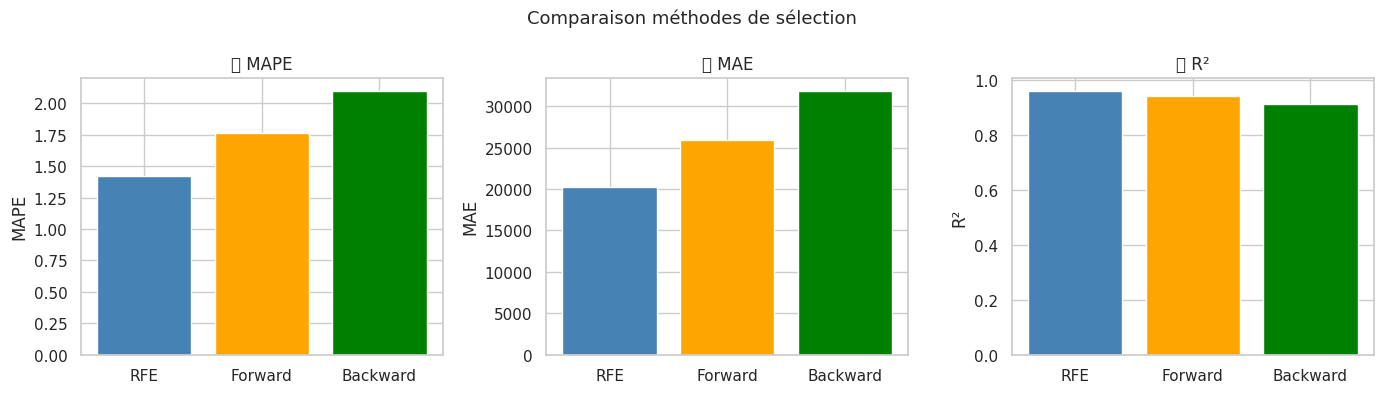

In [27]:
df_sel = pd.DataFrame([
    {'Méthode': 'RFE',      'MAE': mae_rfe, 'MAPE': mape_rfe, 'R²': r2_rfe,  'Biais': bias_rfe,  'features': features_rfe},
    {'Méthode': 'Forward',  'MAE': mae_fwd, 'MAPE': mape_fwd, 'R²': r2_fwd,  'Biais': bias_fwd,  'features': features_fwd},
    {'Méthode': 'Backward', 'MAE': mae_bwd, 'MAPE': mape_bwd, 'R²': r2_bwd,  'Biais': bias_bwd,  'features': features_bwd},
])

print('='*65)
print(f'{"Méthode":<12} {"MAE":>10} {"MAPE":>8} {"R²":>8} {"Biais":>12}')
print('='*65)
for _, row in df_sel.iterrows():
    print(f'{row["Méthode"]:<12} {row["MAE"]:>10,.0f} {row["MAPE"]:>7.2f}% {row["R²"]:>8.4f} {row["Biais"]:>12,.0f}')
print('='*65)

# Meilleure méthode selon MAPE
best_sel_idx   = df_sel['MAPE'].idxmin()
best_sel_name  = df_sel.loc[best_sel_idx, 'Méthode']
FEATURES_FINAL = df_sel.loc[best_sel_idx, 'features']

print(f'\n🏆 Meilleure méthode : {best_sel_name} (MAPE={df_sel.loc[best_sel_idx, "MAPE"]:.2f}%)')
print(f'   Features retenues ({len(FEATURES_FINAL)}) : {FEATURES_FINAL}')

# Variables contemporaines
ALL_CONTEMPORAINES = [
    'nb_clients', 'nb_documents', 'total_quantity',
    'nb_clients_btob', 'nb_clients_btoc', 'nb_clients_actifs',
    'nb_families', 'nb_brands', 'nb_produits',
    'nb_regions', 'nb_warehouses',
    'avg_discount', 'total_discount', 'avg_line_price', 'avg_cost_price',
]
CONTEMPORAINES_FINAL = [f for f in ALL_CONTEMPORAINES if f in FEATURES_FINAL]
print(f'   Contemporaines    ({len(CONTEMPORAINES_FINAL)}) : {CONTEMPORAINES_FINAL}')

# Graphe comparaison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ['MAPE', 'MAE', 'R²']):
    colors = ['steelblue', 'orange', 'green']
    ax.bar(df_sel['Méthode'], df_sel[metric], color=colors)
    ax.set_title(f'📊 {metric}')
    ax.set_ylabel(metric)
plt.suptitle('Comparaison méthodes de sélection', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Préparation des données avec features sélectionnées

In [28]:
X = df_ml[FEATURES_FINAL]
y = df_ml[TARGET]

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'✅ Features finales ({len(FEATURES_FINAL)}) : {FEATURES_FINAL}')
print(f'   X_train : {X_train.shape}')
print(f'   X_test  : {X_test.shape}')

✅ Features finales (8) : ['total_quantity', 'nb_documents', 'nb_clients', 'nb_clients_btob', 'nb_brands', 'nb_produits', 'total_discount', 'avg_line_price']
   X_train : (40, 8)
   X_test  : (5, 8)


## 10. Comparaison de tous les modèles

In [29]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred  = model.predict(X_te)
    mae   = mean_absolute_error(y_te, pred)
    rmse  = np.sqrt(mean_squared_error(y_te, pred))
    r2    = r2_score(y_te, pred)
    mape  = np.mean(np.abs((y_te - pred) / y_te)) * 100
    smape = np.mean(2 * np.abs(y_te - pred) / (np.abs(y_te) + np.abs(pred))) * 100
    bias  = np.mean(pred - y_te)
    return {
        'name': name, 'model': model, 'pred': pred,
        'MAE': mae, 'RMSE': rmse, 'R²': r2,
        'MAPE': mape, 'SMAPE': smape, 'Biais': bias
    }

models_config = [
    # ── Linéaires ─────────────────────────────────────────────
    ('LinearRegression', LinearRegression(),                                                          X_train_sc, X_test_sc),
    ('Ridge',            Ridge(alpha=10),                                                             X_train_sc, X_test_sc),
    ('Lasso',            Lasso(alpha=10),                                                             X_train_sc, X_test_sc),
    ('HuberRegressor',   HuberRegressor(),                                                            X_train_sc, X_test_sc),
    # ── Bagging ───────────────────────────────────────────────
    ('RandomForest',     RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),      X_train,    X_test),
    ('ExtraTrees',       ExtraTreesRegressor(n_estimators=100, max_depth=5, random_state=42),        X_train,    X_test),
    # ── Boosting ──────────────────────────────────────────────
    ('GBT',              GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42), X_train, X_test),
    ('XGBoost',          XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42),             X_train, X_test),
    ('AdaBoost',         AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=42),   X_train,    X_test),
   
]

results = []
for name, model, Xtr, Xte in models_config:
    r = evaluate(name, model, Xtr, y_train, Xte, y_test)
    results.append(r)
    print(f'  ✅ {name:<20} MAPE={r["MAPE"]:.2f}%  R²={r["R²"]:.4f}')

df_results = pd.DataFrame(results).set_index('name')

print('\n' + '=' * 90)
print(f'{"Modèle":<20} {"MAE":>10} {"RMSE":>10} {"R²":>8} {"MAPE":>8} {"SMAPE":>8} {"Biais":>12}')
print('=' * 90)
for _, row in df_results.sort_values('MAPE').iterrows():
    print(f'{row.name:<20} {row["MAE"]:>10,.0f} {row["RMSE"]:>10,.0f} '
          f'{row["R²"]:>8.4f} {row["MAPE"]:>7.2f}% {row["SMAPE"]:>7.2f}% {row["Biais"]:>12,.0f}')
print('=' * 90)

best_name = df_results['MAPE'].idxmin()
print(f'\n🏆 Meilleur modèle : {best_name} (MAPE={df_results.loc[best_name, "MAPE"]:.2f}%  R²={df_results.loc[best_name, "R²"]:.4f})')

  ✅ LinearRegression     MAPE=1.42%  R²=0.9584
  ✅ Ridge                MAPE=2.10%  R²=0.8895
  ✅ Lasso                MAPE=1.42%  R²=0.9583
  ✅ HuberRegressor       MAPE=2.02%  R²=0.8862
  ✅ RandomForest         MAPE=4.19%  R²=0.6504
  ✅ ExtraTrees           MAPE=2.27%  R²=0.8891
  ✅ GBT                  MAPE=2.58%  R²=0.7472
  ✅ XGBoost              MAPE=5.69%  R²=0.3472
  ✅ LightGBM             MAPE=23.12%  R²=-8.9572
  ✅ AdaBoost             MAPE=2.46%  R²=0.8729
  ✅ SVR                  MAPE=21.56%  R²=-7.8210

Modèle                      MAE       RMSE       R²     MAPE    SMAPE        Biais
Lasso                    20,253     24,281   0.9583    1.42%    1.43%       -8,591
LinearRegression         20,288     24,273   0.9584    1.42%    1.43%       -8,673
HuberRegressor           30,468     40,138   0.8862    2.02%    2.05%      -28,382
Ridge                    31,964     39,540   0.8895    2.10%    2.13%      -27,740
ExtraTrees               34,521     39,617   0.8891    2.27%   

## 11. Visualisation CA Réel vs Prédit — tous les modèles

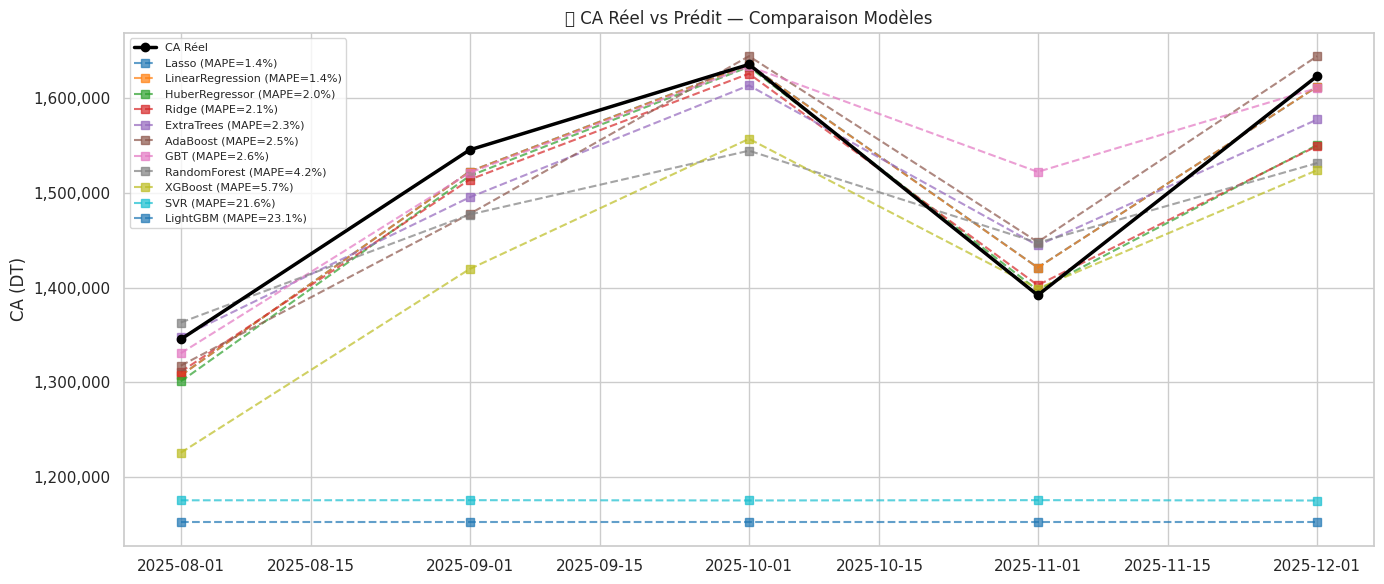

In [30]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_test['date'], y_test.values,
        label='CA Réel', color='black', marker='o', linewidth=2.5, zorder=5)

palette = plt.cm.tab10.colors
for i, (_, row) in enumerate(df_results.sort_values('MAPE').iterrows()):
    ax.plot(df_test['date'], row['pred'],
            label=f"{row.name} (MAPE={row['MAPE']:.1f}%)",
            marker='s', linestyle='--', color=palette[i % len(palette)], alpha=0.7)

ax.set_title('📈 CA Réel vs Prédit — Comparaison Modèles')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 12. Détail mois par mois — meilleur modèle

In [31]:
best = df_results.loc[best_name]

df_detail = df_test[['date']].copy()
df_detail['reel']   = y_test.values
df_detail['predit'] = best['pred']
df_detail['ecart']  = best['pred'] - y_test.values
df_detail['ecart%'] = (df_detail['ecart'] / df_detail['reel'] * 100).round(2)

print(f'=== Détail {best_name} ({best_sel_name}) ===\n')
print(df_detail.to_string(index=False))
print(f"\nBiais : {best['Biais']:,.2f} DT  ({'surestimation' if best['Biais'] > 0 else 'sous-estimation'})")

=== Détail Lasso (RFE) ===

      date         reel       predit      ecart  ecart%
2025-08-01 1,345,444.27 1,307,314.69 -38,129.57   -2.83
2025-09-01 1,545,185.37 1,522,413.72 -22,771.66   -1.47
2025-10-01 1,635,378.39 1,635,380.65       2.26    0.00
2025-11-01 1,391,948.18 1,421,101.31  29,153.13    2.09
2025-12-01 1,623,158.26 1,611,950.29 -11,207.97   -0.69

Biais : -8,590.76 DT  (sous-estimation)


## 13. Vérification Overfitting

In [32]:
best_model_obj = df_results.loc[best_name, 'model']
use_scaler_best = best_name in ['LinearRegression', 'Ridge', 'Lasso', 'HuberRegressor', 'SVR']

pred_train_check = best_model_obj.predict(X_train_sc if use_scaler_best else X_train)

r2_train   = r2_score(y_train, pred_train_check)
r2_test_v  = df_results.loc[best_name, 'R²']
mape_train = np.mean(np.abs((y_train - pred_train_check) / y_train)) * 100
mape_test_v = df_results.loc[best_name, 'MAPE']

print(f'=== Vérification Overfitting — {best_name} ===')
print(f'{"":20} {"TRAIN":>10} {"TEST":>10}')
print(f'{"-"*42}')
print(f'{"MAPE":20} {mape_train:>9.2f}% {mape_test_v:>9.2f}%')
print(f'{"R²":20} {r2_train:>10.4f} {r2_test_v:>10.4f}')
print(f'{"-"*42}')
print(f'Écart MAPE : {abs(mape_train - mape_test_v):.2f}%')
print(f'Écart R²   : {abs(r2_train - r2_test_v):.4f}')

if abs(mape_train - mape_test_v) < 1.0:
    print('\n✅ Pas d\'overfitting !')
elif abs(mape_train - mape_test_v) < 2.5:
    print('\n⚠️  Légère tendance — acceptable')
else:
    print('\n❌ Overfitting détecté')

=== Vérification Overfitting — Lasso ===
                          TRAIN       TEST
------------------------------------------
MAPE                      2.34%      1.42%
R²                       0.9812     0.9583
------------------------------------------
Écart MAPE : 0.92%
Écart R²   : 0.0228

✅ Pas d'overfitting !


## 14. Réentraîner sur tout le dataset + Sauvegarde

In [33]:
print(f'Réentraînement de {best_name} sur {len(df_ml)} mois...')

use_scaler    = best_name in ['LinearRegression', 'Ridge', 'Lasso', 'HuberRegressor', 'SVR']
scaler_final  = StandardScaler()

if use_scaler:
    X_full_sc   = scaler_final.fit_transform(X)
    model_final = type(best_model_obj)(**best_model_obj.get_params())
    model_final.fit(X_full_sc, y)
else:
    model_final = type(best_model_obj)(**best_model_obj.get_params())
    model_final.fit(X, y)
    scaler_final = scaler

# Sauvegarder
joblib.dump(model_final,  '/app/notebooks/best_model.pkl')
joblib.dump(scaler_final, '/app/notebooks/scaler.pkl')

config = {
    'best_model':           best_name,
    'selection_method':     best_sel_name,
    'use_scaler':           use_scaler,
    'features_final':       list(FEATURES_FINAL),
    'contemporaines':       CONTEMPORAINES_FINAL,
    'mape_test':            float(best['MAPE']),
    'mae_test':             float(best['MAE']),
    'r2_test':              float(best['R²']),
    'biais_test':           float(best['Biais']),
}
with open('/app/notebooks/model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(f'✅ Modèle sauvegardé : {best_name}')
print(f'   Méthode sélection : {best_sel_name}')
print(f'   Features ({len(FEATURES_FINAL)}) : {FEATURES_FINAL}')
print(f'   MAPE test  : {best["MAPE"]:.2f}%')
print(f'   R² test    : {best["R²"]:.4f}')
print(f'   Biais test : {best["Biais"]:,.0f} DT')

Réentraînement de Lasso sur 45 mois...
✅ Modèle sauvegardé : Lasso
   Méthode sélection : RFE
   Features (8) : ['total_quantity', 'nb_documents', 'nb_clients', 'nb_clients_btob', 'nb_brands', 'nb_produits', 'total_discount', 'avg_line_price']
   MAPE test  : 1.42%
   R² test    : 0.9583
   Biais test : -8,591 DT


## 15. Prédiction Jan 2026 → Déc 2026

In [34]:
INTEGER_COLS = [
    'nb_clients', 'nb_documents', 'total_quantity',
    'nb_clients_btob', 'nb_clients_btoc', 'nb_clients_actifs',
    'nb_families', 'nb_brands', 'nb_produits',
    'nb_regions', 'nb_warehouses',
]

df_future = df_ml.copy()
last_date = df_future['date'].max()  # Déc 2025
all_sales = list(df_future['total_sales'])

print(f'Modèle   : {best_name} (sélection {best_sel_name})')
print(f'Départ   : {last_date.strftime("%b %Y")}')
print(f'Objectif : Jan 2026 → Déc 2026\n')

predictions = []

for i in range(1, 13):
    next_date  = last_date + pd.DateOffset(months=i)
    next_month = next_date.month
    next_year  = next_date.year

    row = {}

    # ── Temporelles
    if 'year'        in FEATURES_FINAL: row['year']        = next_year
    if 'month'       in FEATURES_FINAL: row['month']       = next_month
    if 'quarter'     in FEATURES_FINAL: row['quarter']     = (next_month - 1) // 3 + 1
    if 'semester'    in FEATURES_FINAL: row['semester']    = 1 if next_month <= 6 else 2
    if 'is_summer'   in FEATURES_FINAL: row['is_summer']   = 1 if next_month in [7, 8] else 0
    if 'is_end_year' in FEATURES_FINAL: row['is_end_year'] = 1 if next_month in [11, 12] else 0
    if 'is_january'  in FEATURES_FINAL: row['is_january']  = 1 if next_month == 1 else 0

    # ── Lags (depuis all_sales qui grandit)
    if 'lag_1'  in FEATURES_FINAL: row['lag_1']  = all_sales[-1]
    if 'lag_12' in FEATURES_FINAL:
        row['lag_12'] = all_sales[-12] if len(all_sales) >= 12 else np.mean(all_sales)

    # ── Rolling
    if 'rolling_mean_3' in FEATURES_FINAL:
        row['rolling_mean_3'] = np.mean(all_sales[-3:])

    # ── Contemporaines → moyenne du même mois (saisonnalité)
    for col in CONTEMPORAINES_FINAL:
        if col in FEATURES_FINAL:
            same_month = df_future[df_future['month'] == next_month][col]
            vals = same_month if len(same_month) > 0 else df_future[col]

            # Médiane plus robuste aux outliers
            val = vals.median()
            row[col] = int(round(val)) if col in INTEGER_COLS else val

    # ── Prédiction
    X_row = pd.DataFrame([row])[FEATURES_FINAL]
    if use_scaler:
        pred = model_final.predict(scaler_final.transform(X_row))[0]
    else:
        pred = model_final.predict(X_row)[0]

    all_sales.append(pred)
    predictions.append({
        'date': next_date, 'year': next_year, 'month': next_month,
        'predicted_sales': pred, 'is_prediction': 1
    })
    print(f'  {next_date.strftime("%b %Y")} → {pred:>15,.2f} DT')

df_pred = pd.DataFrame(predictions)
print(f'\n✅ 12 mois prédits (Jan 2026 → Déc 2026)')
print(f'CA prévisionnel 2026 : {df_pred["predicted_sales"].sum():,.2f} DT')

Modèle   : Lasso (sélection RFE)
Départ   : Dec 2025
Objectif : Jan 2026 → Déc 2026

  Jan 2026 →    1,216,753.73 DT
  Feb 2026 →    1,134,539.78 DT
  Mar 2026 →    1,105,186.17 DT
  Apr 2026 →      973,542.94 DT
  May 2026 →    1,229,134.39 DT
  Jun 2026 →    1,135,683.50 DT
  Jul 2026 →    1,298,252.83 DT
  Aug 2026 →    1,201,024.02 DT
  Sep 2026 →    1,392,346.48 DT
  Oct 2026 →    1,413,720.61 DT
  Nov 2026 →    1,297,672.78 DT
  Dec 2026 →    1,377,764.86 DT

✅ 12 mois prédits (Jan 2026 → Déc 2026)
CA prévisionnel 2026 : 14,775,622.09 DT


## 16. Visualisation finale — Réel + Prédit

In [35]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_ml['date'], y=df_ml['total_sales'],
    name='CA Réel', mode='lines+markers',
    line=dict(color='steelblue', width=2), marker=dict(size=5)
))

fig.add_trace(go.Scatter(
    x=df_pred['date'], y=df_pred['predicted_sales'],
    name=f'CA Prédit 2026 ({best_name})',
    mode='lines+markers',
    line=dict(color='orange', width=2, dash='dash'),
    marker=dict(size=6, symbol='square')
))

fig.add_vline(
    x=last_date.timestamp() * 1000,
    line_dash='dot', line_color='red',
    annotation_text='Déc 2025 — Fin données réelles'
)

fig.update_layout(
    title=f'📈 CA Réel (Jan 2022 → Déc 2025) + Prédit (Jan 2026 → Déc 2026) — {best_name} | {best_sel_name}',
    xaxis_title='Mois', yaxis_title='CA (DT)',
    hovermode='x unified', height=500
)
fig.show()

## 17. CA annuel — 2024 Réel | 2025 Réel | 2026 Prédit

📋 PRÉVISION CA ANNUEL 2026
CA réel 2024        :   15,843,689.48 DT
CA réel 2025        :   16,342,751.14 DT
CA prévu 2026       :   14,775,622.09 DT
Croissance 25→26   :           -9.59 %
Modèle              : Lasso
Sélection features  : RFE
MAPE test          : 1.42%
R² test            : 0.9583

Détail mensuel 2026 :
      date  predicted_sales
2026-01-01     1,216,753.73
2026-02-01     1,134,539.78
2026-03-01     1,105,186.17
2026-04-01       973,542.94
2026-05-01     1,229,134.39
2026-06-01     1,135,683.50
2026-07-01     1,298,252.83
2026-08-01     1,201,024.02
2026-09-01     1,392,346.48
2026-10-01     1,413,720.61
2026-11-01     1,297,672.78
2026-12-01     1,377,764.86


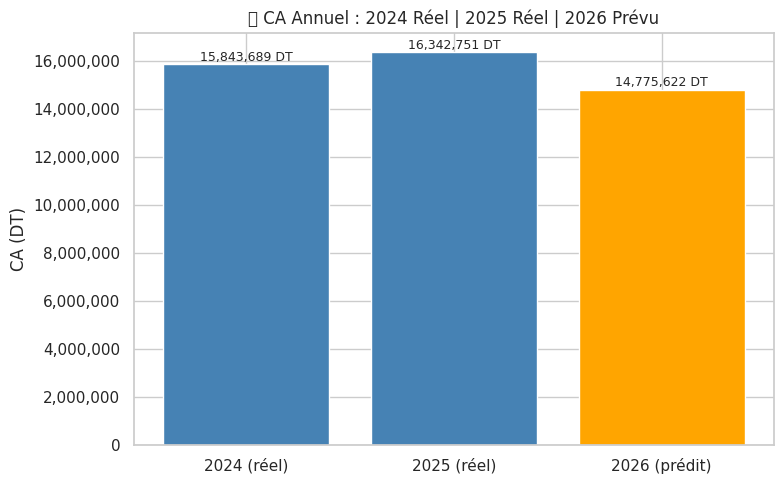

In [36]:
ca_2024    = df_ml[df_ml['date'].dt.year == 2024]['total_sales'].sum()
ca_2025    = df_ml[df_ml['date'].dt.year == 2025]['total_sales'].sum()
ca_2026    = df_pred['predicted_sales'].sum()
croissance = (ca_2026 - ca_2025) / ca_2025 * 100

print('=' * 60)
print('📋 PRÉVISION CA ANNUEL 2026')
print('=' * 60)
print(f'CA réel 2024        : {ca_2024:>15,.2f} DT')
print(f'CA réel 2025        : {ca_2025:>15,.2f} DT')
print(f'CA prévu 2026       : {ca_2026:>15,.2f} DT')
print(f'Croissance 25→26   : {croissance:>15.2f} %')
print(f'Modèle              : {best_name}')
print(f'Sélection features  : {best_sel_name}')
print(f'MAPE test          : {best["MAPE"]:.2f}%')
print(f'R² test            : {best["R²"]:.4f}')
print('=' * 60)
print('\nDétail mensuel 2026 :')
print(df_pred[['date', 'predicted_sales']].to_string(index=False))

# Graphe annuel
years_data = pd.DataFrame([
    {'Année': '2024 (réel)',  'CA': ca_2024},
    {'Année': '2025 (réel)',  'CA': ca_2025},
    {'Année': '2026 (prédit)','CA': ca_2026},
])
fig, ax = plt.subplots(figsize=(8, 5))
colors  = ['steelblue', 'steelblue', 'orange']
ax.bar(years_data['Année'], years_data['CA'], color=colors)
for i, (_, r) in enumerate(years_data.iterrows()):
    ax.text(i, r['CA'] + years_data['CA'].max() * 0.01,
            f"{r['CA']:,.0f} DT", ha='center', fontsize=9)
ax.set_title('📊 CA Annuel : 2024 Réel | 2025 Réel | 2026 Prévu')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

## 18. Écriture dans ClickHouse Gold

In [37]:
client2 = clickhouse_connect.get_client(
    host='clickhouse', port=8123,
    user='default', password='clickhouse123',
    database='gold'
)

client2.command("""
    CREATE TABLE IF NOT EXISTS gold.ml_predictions (
        date             Date,
        year             Int32,
        month            Int32,
        predicted_sales  Float64,
        is_prediction    Int8
    ) ENGINE = MergeTree() ORDER BY date
""")

client2.command('TRUNCATE TABLE gold.ml_predictions')
client2.insert_df('gold.ml_predictions',
    df_pred[['date', 'year', 'month', 'predicted_sales', 'is_prediction']])

check = client2.query_df('SELECT * FROM gold.ml_predictions ORDER BY date')
print(f'✅ {len(check)} prédictions écrites dans ClickHouse Gold')
print('   Table : gold.ml_predictions\n')
print(check.to_string(index=False))

✅ 12 prédictions écrites dans ClickHouse Gold
   Table : gold.ml_predictions

      date  year  month  predicted_sales  is_prediction
2026-01-01  2026      1     1,216,753.73              1
2026-02-01  2026      2     1,134,539.78              1
2026-03-01  2026      3     1,105,186.17              1
2026-04-01  2026      4       973,542.94              1
2026-05-01  2026      5     1,229,134.39              1
2026-06-01  2026      6     1,135,683.50              1
2026-07-01  2026      7     1,298,252.83              1
2026-08-01  2026      8     1,201,024.02              1
2026-09-01  2026      9     1,392,346.48              1
2026-10-01  2026     10     1,413,720.61              1
2026-11-01  2026     11     1,297,672.78              1
2026-12-01  2026     12     1,377,764.86              1


In [38]:
print("Détail prédictions vs historique même mois :\n")
print(f"{'Mois':<12} {'Prédit 2026':>15} {'Réel 2025':>15} {'Réel 2024':>15} {'Diff%':>8}")
print("-"*65)

for _, row in df_pred.iterrows():
    m    = row['month']
    pred = row['predicted_sales']

    reel_2025 = df_ml[(df_ml['date'].dt.year == 2025) &
                      (df_ml['date'].dt.month == m)]['total_sales']
    reel_2024 = df_ml[(df_ml['date'].dt.year == 2024) &
                      (df_ml['date'].dt.month == m)]['total_sales']

    v2025 = reel_2025.values[0] if len(reel_2025) > 0 else 0
    v2024 = reel_2024.values[0] if len(reel_2024) > 0 else 0
    diff  = (pred - v2025) / v2025 * 100 if v2025 > 0 else 0

    print(f"{row['date'].strftime('%b %Y'):<12} {pred:>15,.0f} {v2025:>15,.0f} {v2024:>15,.0f} {diff:>7.1f}%")

Détail prédictions vs historique même mois :

Mois             Prédit 2026       Réel 2025       Réel 2024    Diff%
-----------------------------------------------------------------
Jan 2026           1,216,754       1,043,000       1,257,498    16.7%
Feb 2026           1,134,540       1,212,738       1,107,675    -6.4%
Mar 2026           1,105,186       1,004,936       1,208,758    10.0%
Apr 2026             973,543       1,233,784       1,157,346   -21.1%
May 2026           1,229,134       1,240,759       1,435,948    -0.9%
Jun 2026           1,135,684       1,422,307       1,302,958   -20.2%
Jul 2026           1,298,253       1,644,113       1,481,827   -21.0%
Aug 2026           1,201,024       1,345,444       1,509,045   -10.7%
Sep 2026           1,392,346       1,545,185       1,424,779    -9.9%
Oct 2026           1,413,721       1,635,378       1,385,051   -13.6%
Nov 2026           1,297,673       1,391,948       1,165,524    -6.8%
Dec 2026           1,377,765       1,623,158    